# Hito 1 - Notebook 04: Comprension de Datos y EDA - Frente Logistica
## Fase 2 de CRISP-DM (dataset de inventario / supply chain)

Analisis exploratorio del dataset logistico, incluyendo la **exploracion temporal** necesaria para el pronostico de stock a 7 y 14 dias.

In [1]:
import sys
from pathlib import Path
import warnings; warnings.filterwarnings('ignore')
ROOT = Path.cwd()
while not (ROOT / 'src' / 'aldimi_common.py').exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / 'src'))
import aldimi_common as ac
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
%matplotlib inline
sns.set_theme(style='whitegrid'); plt.rcParams['figure.figsize'] = (9, 5)
pd.set_option('display.max_columns', None)
print('Raiz del proyecto:', ROOT)

Raiz del proyecto: D:\2026-01\MachLearning\finTF


In [2]:
stock_raw = pd.read_csv(ac.DATA_RAW / ac.STOCK_RAW_FILE)
print('Dimensiones:', stock_raw.shape)
stock_raw.head()

Dimensiones: (91250, 15)


,Date,SKU_ID,Warehouse_ID,Supplier_ID,Region,Units_Sold,Inventory_Level,Supplier_Lead_Time_Days,Reorder_Point,Order_Quantity,Unit_Cost,Unit_Price,Promotion_Flag,Stockout_Flag,Demand_Forecast
0,2024-01-01,SKU_1,WH_1,SUP_8,West,10,592,14,379,0,13.95,20.48,0,0,8.52
1,2024-01-02,SKU_1,WH_1,SUP_8,West,17,575,14,379,0,13.95,20.48,0,0,18.63
2,2024-01-03,SKU_1,WH_1,SUP_8,North,35,540,14,379,0,13.95,20.48,1,0,39.62
3,2024-01-04,SKU_1,WH_1,SUP_8,South,24,516,14,379,0,13.95,20.48,0,0,19.43
4,2024-01-05,SKU_1,WH_1,SUP_8,West,21,495,14,379,0,13.95,20.48,0,0,18.70


## 1.3.2 Descripcion de los Datos (Diccionario de Variables)

In [3]:
def tipo_variable(s):
    if s.dtype == object:
        return 'Cualitativa Nominal (Dicotomica)' if s.nunique() == 2 else 'Cualitativa Nominal'
    if s.nunique() <= 2:
        return 'Cualitativa Nominal (Dicotomica)'
    return 'Cuantitativa Discreta' if str(s.dtype).startswith('int') else 'Cuantitativa Continua'

diccionario = pd.DataFrame({
    '#': range(1, len(stock_raw.columns) + 1),
    'Variable': stock_raw.columns,
    'Tipo_Python': [str(stock_raw[c].dtype) for c in stock_raw.columns],
    'Tipo_Variable': [tipo_variable(stock_raw[c]) for c in stock_raw.columns],
    'Valores_Unicos': [stock_raw[c].nunique() for c in stock_raw.columns],
})
diccionario

,#,Variable,Tipo_Python,Tipo_Variable,Valores_Unicos
0,1,Date,object,Cualitativa Nominal,365
1,2,SKU_ID,object,Cualitativa Nominal,50
2,3,Warehouse_ID,object,Cualitativa Nominal,5
3,4,Supplier_ID,object,Cualitativa Nominal,10
4,5,Region,object,Cualitativa Nominal,4
5,6,Units_Sold,int64,Cuantitativa Discreta,58
6,7,Inventory_Level,int64,Cuantitativa Discreta,781
7,8,Supplier_Lead_Time_Days,int64,Cuantitativa Discreta,13
8,9,Reorder_Point,int64,Cuantitativa Discreta,142
9,10,Order_Quantity,int64,Cuantitativa Discreta,301


> El dataset tiene granularidad **SKU x Almacen x Dia** (50 SKUs, 5 almacenes, 365 dias). `Stockout_Flag` es constante (todos 0). Para el contexto ALDIMI (un unico albergue) se consolidara por insumo y dia (ver notebook 06).

## 1.3.3 Verificacion de Calidad de los Datos

In [4]:
print('Nulos totales   :', int(stock_raw.isna().sum().sum()))
print('Duplicados      :', int(stock_raw.duplicated().sum()))
print('Stockout_Flag unicos:', stock_raw['Stockout_Flag'].unique())
num_cols = stock_raw.select_dtypes(include=np.number).columns.tolist()
stock_raw[num_cols].describe().T

Nulos totales   :

 0
Duplicados      : 0
Stockout_Flag unicos: [0]


,count,mean,std,min,25%,50%,75%,max
Units_Sold,91250.0,20.054564,9.068602,0.00,13.00,20.00,27.00,59.00
Inventory_Level,91250.0,471.522312,133.488002,168.00,370.00,461.00,564.00,990.00
Supplier_Lead_Time_Days,91250.0,7.984000,3.907929,2.00,4.00,8.00,11.00,14.00
Reorder_Point,91250.0,300.068000,54.879945,201.00,252.00,300.00,346.00,398.00
Order_Quantity,91250.0,19.272493,82.340831,0.00,0.00,0.00,0.00,499.00
Unit_Cost,91250.0,12.203320,4.574982,5.02,8.18,11.99,16.32,19.76
Unit_Price,91250.0,18.261800,7.121136,6.95,12.00,18.18,23.39,35.10
Promotion_Flag,91250.0,0.101589,0.302109,0.00,0.00,0.00,0.00,1.00
Stockout_Flag,91250.0,0.000000,0.000000,0.00,0.00,0.00,0.00,0.00
Demand_Forecast,91250.0,20.082033,9.503955,0.00,12.95,19.95,26.93,61.42


### Deteccion de outliers - Boxplots (Figura 1)

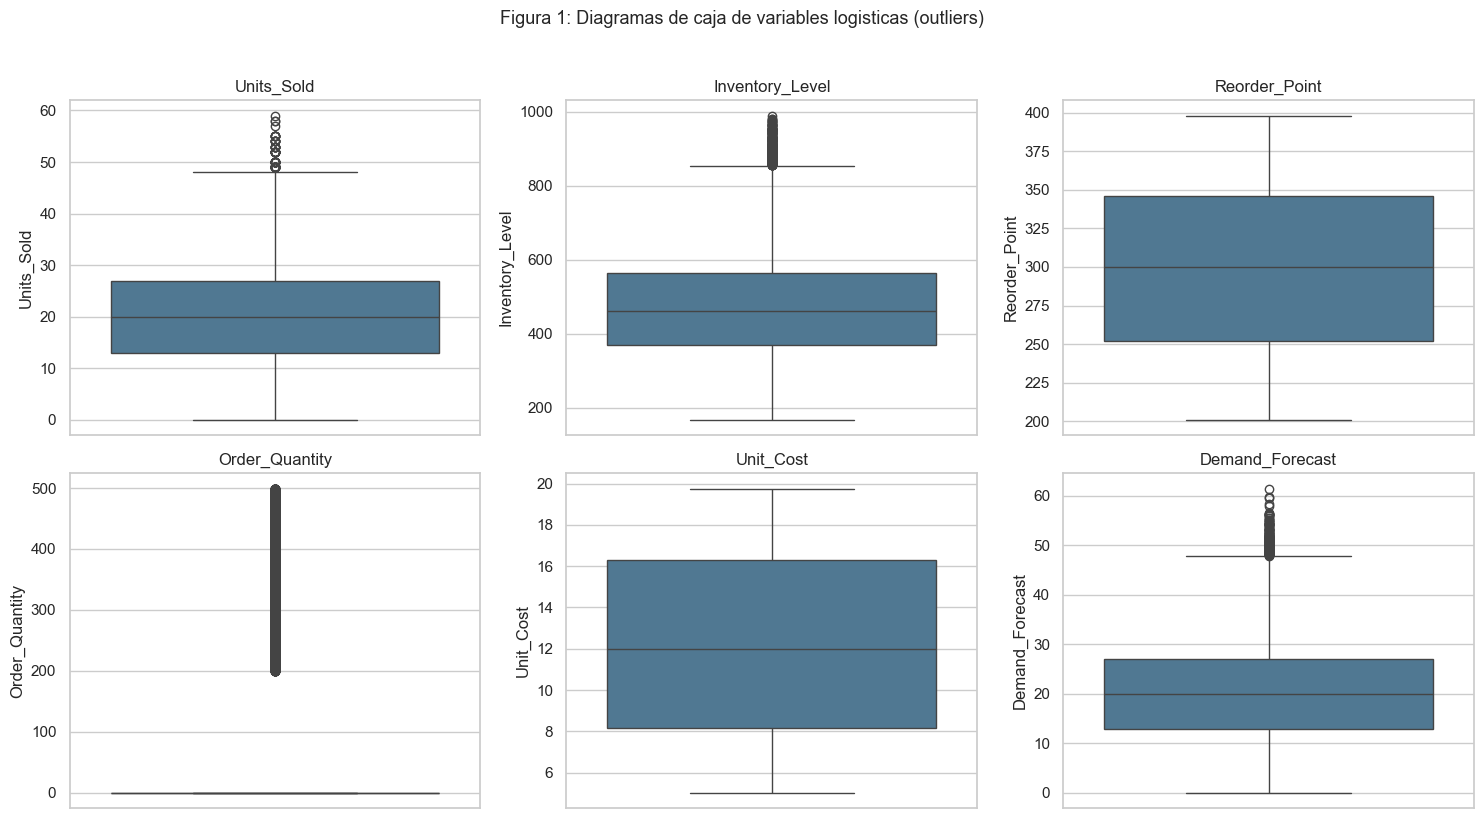

In [5]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, col in zip(axes.ravel(), ['Units_Sold', 'Inventory_Level', 'Reorder_Point', 'Order_Quantity', 'Unit_Cost', 'Demand_Forecast']):
    sns.boxplot(y=stock_raw[col], ax=ax, color='#457b9d'); ax.set_title(col)
fig.suptitle('Figura 1: Diagramas de caja de variables logisticas (outliers)', y=1.02, fontsize=13)
plt.tight_layout(); plt.show()

> **Figura 1.** Existen picos de consumo (Units_Sold) y de Order_Quantity; se conservan por representar eventos reales de demanda/reposicion.

### Metodo Z-score

In [6]:
from scipy import stats
z = np.abs(stats.zscore(stock_raw[num_cols], nan_policy='omit'))
outliers_z = (z > 3).sum(axis=0)
pd.DataFrame({'Variable': num_cols, 'Outliers_|Z|>3': outliers_z, 'Pct': (outliers_z / len(stock_raw) * 100).round(2)})

,Variable,Outliers_|Z|>3,Pct
Units_Sold,Units_Sold,161,0.18
Inventory_Level,Inventory_Level,156,0.17
Supplier_Lead_Time_Days,Supplier_Lead_Time_Days,0,0.00
Reorder_Point,Reorder_Point,0,0.00
Order_Quantity,Order_Quantity,3922,4.30
Unit_Cost,Unit_Cost,0,0.00
Unit_Price,Unit_Price,0,0.00
Promotion_Flag,Promotion_Flag,0,0.00
Stockout_Flag,Stockout_Flag,0,0.00
Demand_Forecast,Demand_Forecast,151,0.17


> **Tratamiento de outliers:** se conservan (demanda real) y se suavizan con **promedios moviles de 7 y 14 dias**, que ademas son las features clave del pronostico.

### Matriz de correlacion (Figura 2)

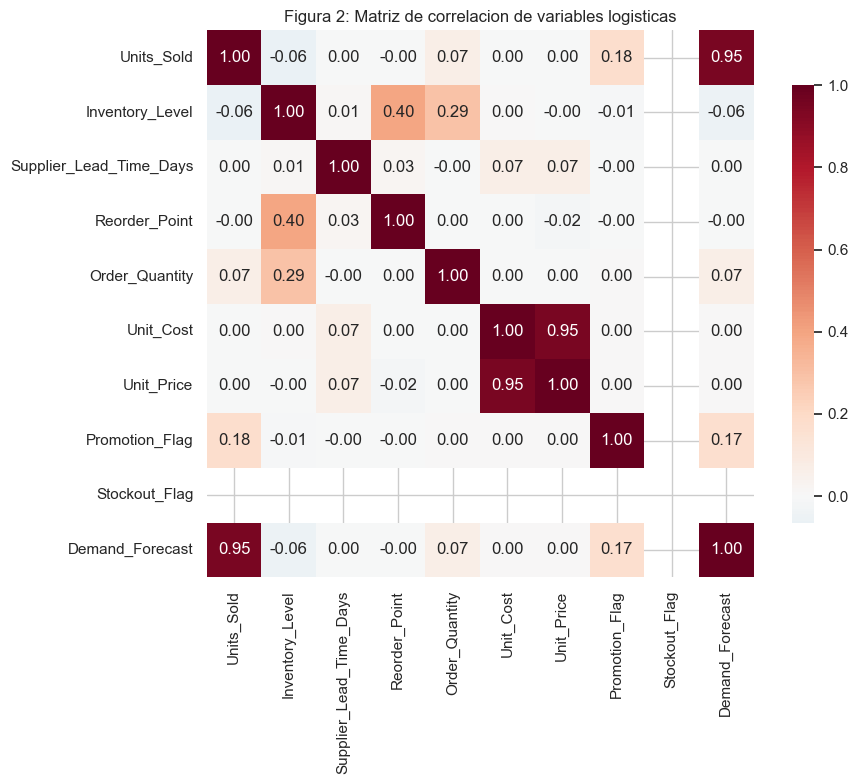

In [7]:
corr = stock_raw[num_cols].corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0, square=True, cbar_kws={'shrink': .8})
plt.title('Figura 2: Matriz de correlacion de variables logisticas')
plt.tight_layout(); plt.show()

> **Figura 2.** `Units_Sold` y `Demand_Forecast` estan fuertemente correlacionadas (el pronostico sigue la demanda); `Reorder_Point` se relaciona con el nivel de inventario. Esto valida usar la demanda y el punto de reorden como predictores del stock futuro.

### Matriz de covarianza y multicolinealidad (VIF)

In [8]:
display(stock_raw[num_cols].cov().round(2))
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.preprocessing import StandardScaler
Xv = StandardScaler().fit_transform(stock_raw[num_cols].fillna(0))
vif = pd.DataFrame({'Variable': num_cols, 'VIF': [variance_inflation_factor(Xv, i) for i in range(Xv.shape[1])]})
vif.sort_values('VIF', ascending=False)

,Units_Sold,Inventory_Level,Supplier_Lead_Time_Days,Reorder_Point,Order_Quantity,Unit_Cost,Unit_Price,Promotion_Flag,Stockout_Flag,Demand_Forecast
Units_Sold,82.24,-77.82,0.02,-0.81,51.77,0.07,0.08,0.49,0.0,81.82
Inventory_Level,-77.82,17819.05,6.99,2896.86,3193.17,1.96,-4.24,-0.53,0.0,-75.68
Supplier_Lead_Time_Days,0.02,6.99,15.27,5.76,-0.09,1.28,2.00,-0.00,0.0,0.02
Reorder_Point,-0.81,2896.86,5.76,3011.81,9.52,0.45,-6.45,-0.03,0.0,-0.41
Order_Quantity,51.77,3193.17,-0.09,9.52,6780.01,0.07,0.08,0.06,0.0,52.91
Unit_Cost,0.07,1.96,1.28,0.45,0.07,20.93,30.82,0.00,0.0,0.14
Unit_Price,0.08,-4.24,2.00,-6.45,0.08,30.82,50.71,0.01,0.0,0.20
Promotion_Flag,0.49,-0.53,-0.00,-0.03,0.06,0.00,0.01,0.09,0.0,0.49
Stockout_Flag,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.0,0.00
Demand_Forecast,81.82,-75.68,0.02,-0.41,52.91,0.14,0.20,0.49,0.0,90.33


,Variable,VIF
0,Units_Sold,10.170669
9,Demand_Forecast,10.125101
6,Unit_Price,9.571459
5,Unit_Cost,9.568149
1,Inventory_Level,1.328633
3,Reorder_Point,1.210748
4,Order_Quantity,1.121011
7,Promotion_Flag,1.033712
2,Supplier_Lead_Time_Days,1.006099
8,Stockout_Flag,NaN


> **Conclusion VIF:** `Units_Sold` y `Demand_Forecast` muestran VIF alto (colinealidad esperada); se mantendra solo el aporte no redundante en el modelado.

### Grafico de dispersion (Figura 3)

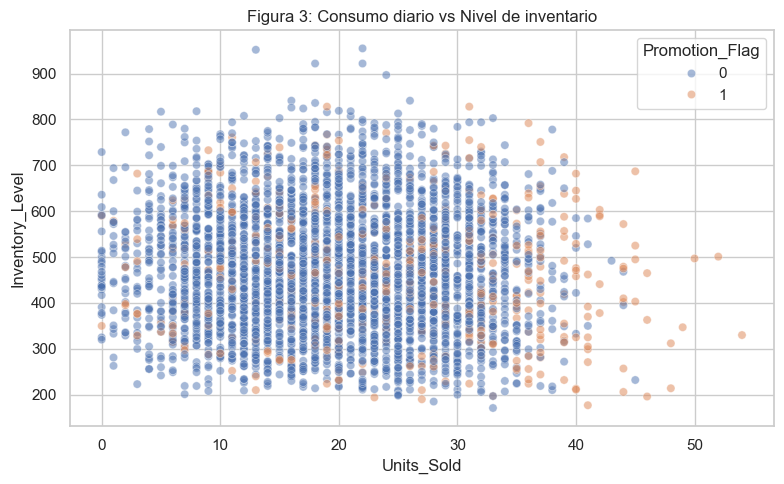

In [9]:
muestra = stock_raw.sample(min(4000, len(stock_raw)), random_state=42)
plt.figure(figsize=(8, 5))
sns.scatterplot(data=muestra, x='Units_Sold', y='Inventory_Level', hue='Promotion_Flag', alpha=.5)
plt.title('Figura 3: Consumo diario vs Nivel de inventario')
plt.tight_layout(); plt.show()

> **Figura 3.** No hay una relacion lineal simple consumo-inventario, lo que justifica modelos no lineales (RF/XGBoost) para el pronostico.

## Pruebas de Normalidad

In [10]:
from scipy import stats
filas = []
for col in num_cols:
    datos = stock_raw[col].dropna().sample(min(5000, stock_raw[col].notna().sum()), random_state=42)
    W, p = stats.shapiro(datos)
    filas.append({'Variable': col, 'Shapiro_W': round(W, 4), 'p_value': round(p, 6), 'Normal': 'Si' if p > 0.05 else 'No'})
pd.DataFrame(filas)

,Variable,Shapiro_W,p_value,Normal
0,Units_Sold,0.9921,0.0,No
1,Inventory_Level,0.9874,0.0,No
2,Supplier_Lead_Time_Days,0.9323,0.0,No
3,Reorder_Point,0.9562,0.0,No
4,Order_Quantity,0.2554,0.0,No
5,Unit_Cost,0.9362,0.0,No
6,Unit_Price,0.9663,0.0,No
7,Promotion_Flag,0.3626,0.0,No
8,Stockout_Flag,1.0000,1.0,Si
9,Demand_Forecast,0.9935,0.0,No


> **Conclusion normalidad:** las variables logisticas no son normales; se confirma el uso de tecnicas robustas/no parametricas.

## 1.3.4 EDA y Exploracion Temporal

### Preparacion contextual (mapeo a insumos ALDIMI + series)

In [11]:
stock = ac.map_insumos(stock_raw)
stock = ac.aggregate_daily_insumo(stock)
stock = ac.add_occupancy_context(stock)
stock = ac.add_stock_features(stock)
print('Serie consolidada por insumo/dia:', stock.shape)
stock[['Fecha', 'Insumo', 'Categoria_Insumo', 'Stock_Actual', 'Consumo_Diario', 'Ratio_Stock', 'Alerta']].head()

Serie consolidada por insumo/dia: (18250, 26)


,Fecha,Insumo,Categoria_Insumo,Stock_Actual,Consumo_Diario,Ratio_Stock,Alerta
0,2024-01-01,Metotrexato,Medicamento Oncologico,3102,81,1.809802,Normal
50,2024-01-02,Metotrexato,Medicamento Oncologico,3023,79,1.763711,Normal
100,2024-01-03,Metotrexato,Medicamento Oncologico,2897,126,1.690198,Normal
150,2024-01-04,Metotrexato,Medicamento Oncologico,2792,105,1.628938,Normal
200,2024-01-05,Metotrexato,Medicamento Oncologico,2690,102,1.569428,Normal


### Distribuciones e histogramas (Figura 4)

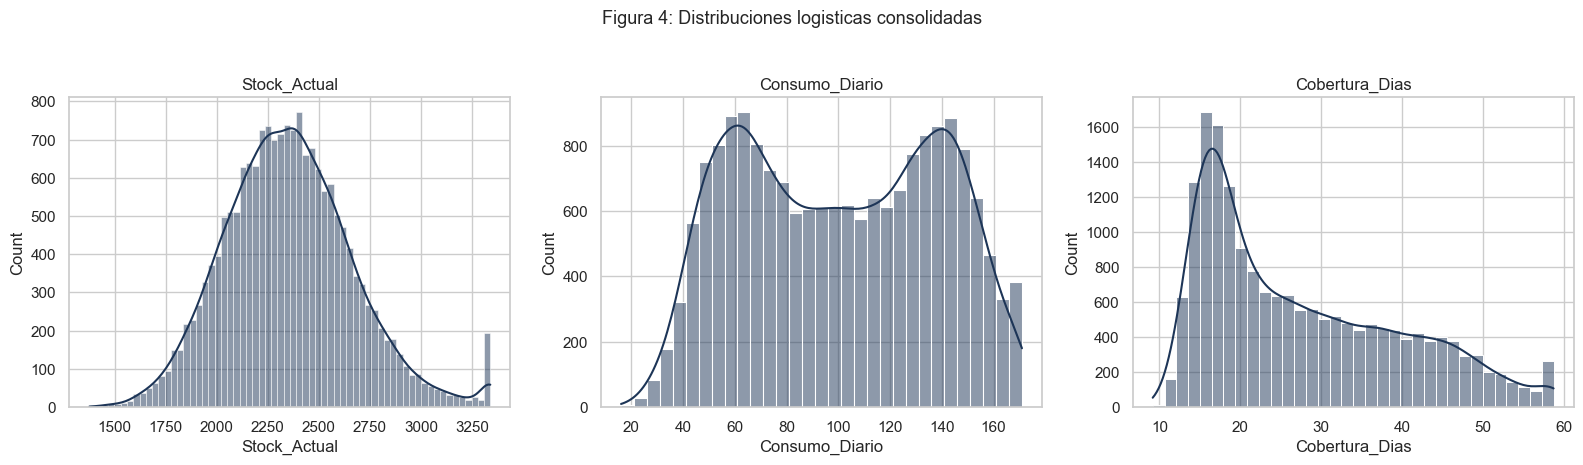

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
for ax, col in zip(axes, ['Stock_Actual', 'Consumo_Diario', 'Cobertura_Dias']):
    sns.histplot(stock[col].clip(upper=stock[col].quantile(.99)), kde=True, ax=ax, color='#1d3557'); ax.set_title(col)
fig.suptitle('Figura 4: Distribuciones logisticas consolidadas', y=1.03, fontsize=13)
plt.tight_layout(); plt.show()

> **Figura 4.** El stock y el consumo muestran variabilidad por insumo; la cobertura en dias permitira definir alertas preventivas/criticas.

### Exploracion temporal - Serie de un insumo (Figura 5)

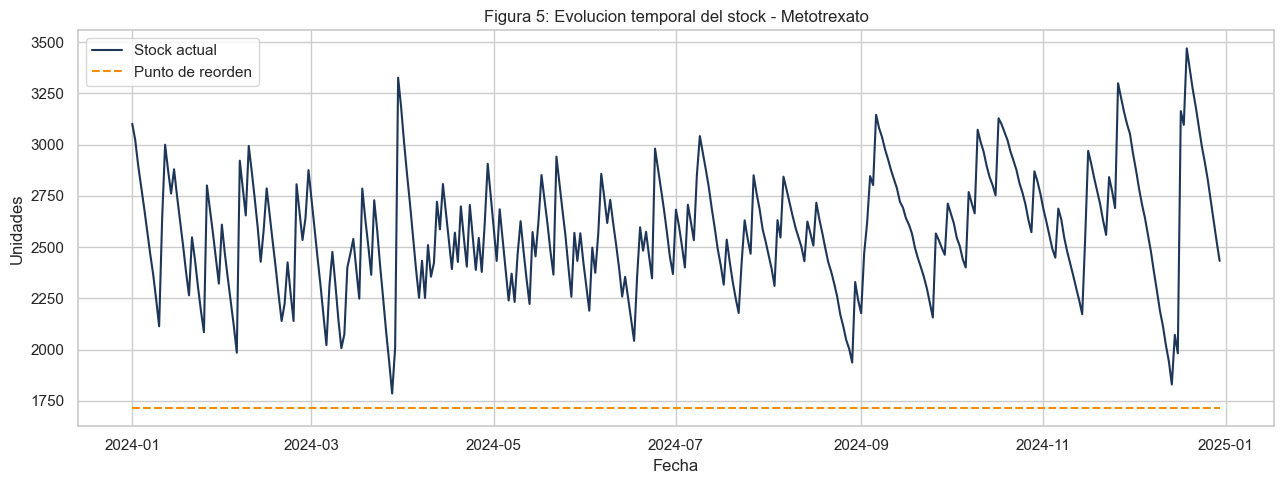

In [13]:
insumo = stock['ID_Insumo'].iloc[0]
serie = stock[stock['ID_Insumo'] == insumo].sort_values('Fecha')
plt.figure(figsize=(13, 5))
plt.plot(serie['Fecha'], serie['Stock_Actual'], label='Stock actual', color='#1d3557')
plt.plot(serie['Fecha'], serie['Punto_Reorden'], label='Punto de reorden', color='#f48c06', ls='--')
plt.title(f'Figura 5: Evolucion temporal del stock - {serie["Insumo"].iloc[0]}')
plt.xlabel('Fecha'); plt.ylabel('Unidades'); plt.legend(); plt.tight_layout(); plt.show()

> **Figura 5.** La serie muestra ciclos de consumo y reposicion; la cercania del stock al punto de reorden es la senal que el modelo debe anticipar a 7 y 14 dias.

### Top categorias de insumos (Figura 6)

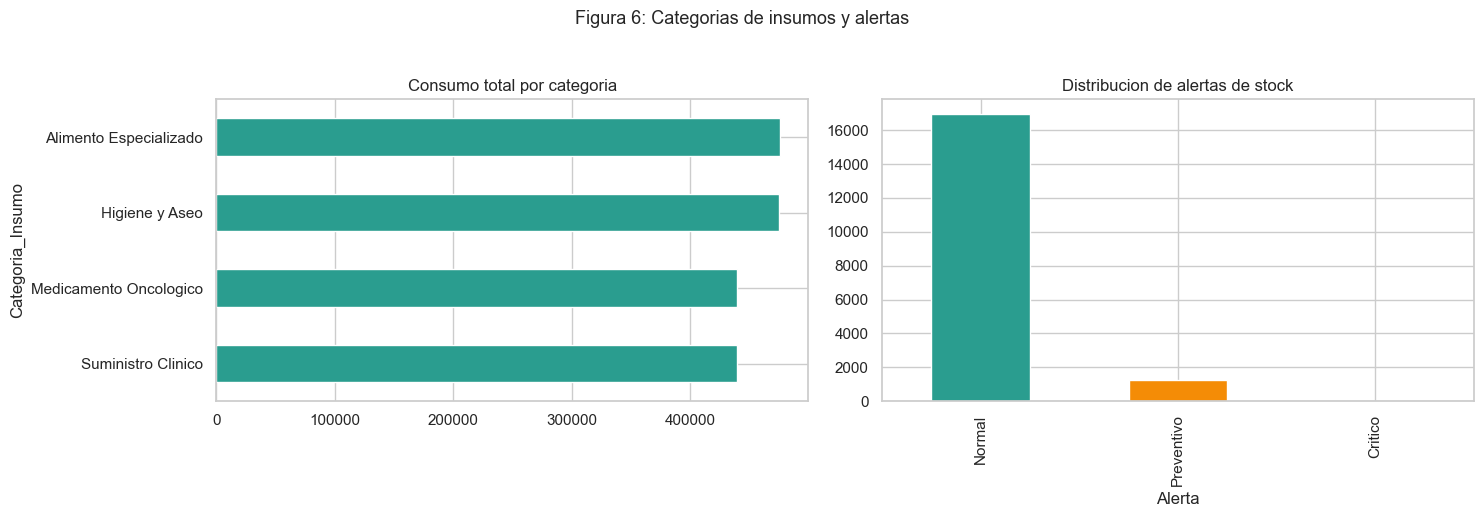

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
stock.groupby('Categoria_Insumo')['Consumo_Diario'].sum().sort_values().plot(kind='barh', ax=axes[0], color='#2a9d8f')
axes[0].set_title('Consumo total por categoria')
stock['Alerta'].value_counts().reindex(['Normal', 'Preventivo', 'Critico']).plot(kind='bar', ax=axes[1],
    color=[ac.ALERT_COLORS[k] for k in ['Normal', 'Preventivo', 'Critico']])
axes[1].set_title('Distribucion de alertas de stock')
fig.suptitle('Figura 6: Categorias de insumos y alertas', y=1.03, fontsize=13)
plt.tight_layout(); plt.show()

> **Figura 6.** Los alimentos especializados y suministros clinicos concentran el mayor consumo; existe una proporcion de registros en alerta que el sistema debe prevenir.

### Heatmap de correlacion (features de series) (Figura 7)

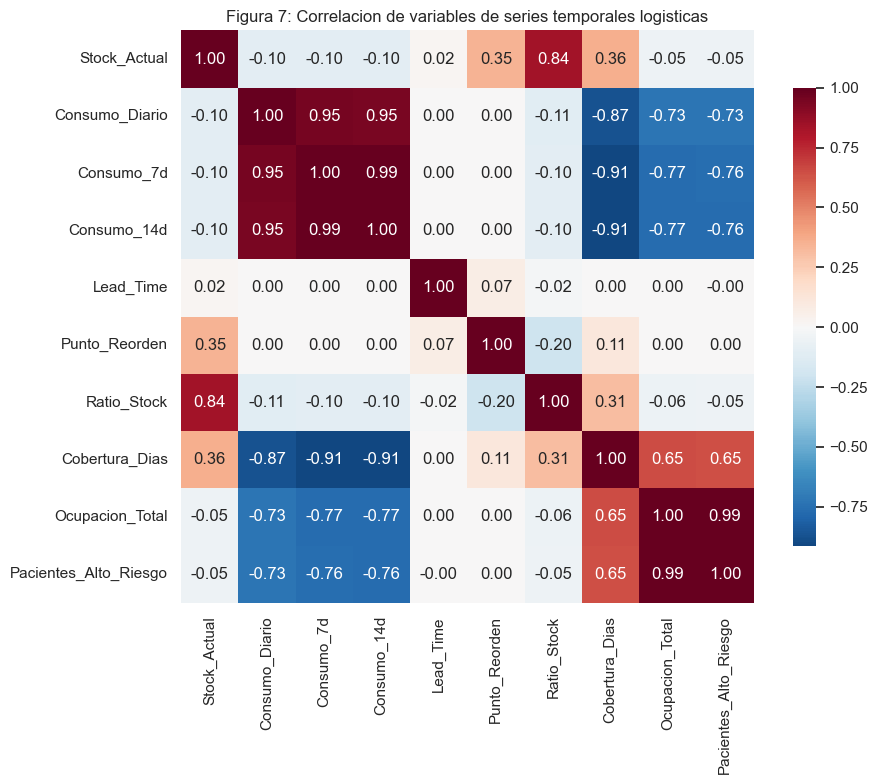

In [15]:
cols_serie = ['Stock_Actual', 'Consumo_Diario', 'Consumo_7d', 'Consumo_14d', 'Lead_Time',
              'Punto_Reorden', 'Ratio_Stock', 'Cobertura_Dias', 'Ocupacion_Total', 'Pacientes_Alto_Riesgo']
plt.figure(figsize=(10, 8))
sns.heatmap(stock[cols_serie].corr(), annot=True, fmt='.2f', cmap='RdBu_r', center=0, square=True, cbar_kws={'shrink': .8})
plt.title('Figura 7: Correlacion de variables de series temporales logisticas')
plt.tight_layout(); plt.show()

> **Figura 7.** Los promedios moviles (Consumo_7d/14d) correlacionan con el consumo diario y con la cobertura, confirmando su utilidad como predictores del stock futuro.

## Reduccion de Dimensionalidad (PCA)

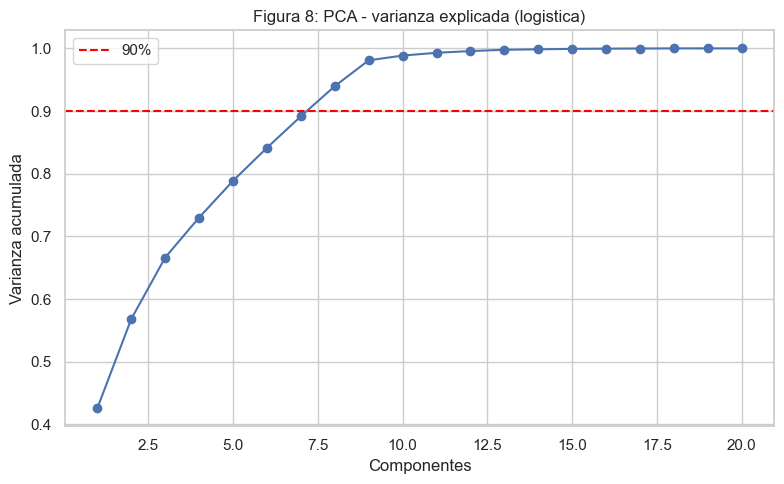

Componentes para 90% varianza: 8 de 20


In [16]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
feats = ac.stock_feature_columns(stock)
Xs = StandardScaler().fit_transform(stock[feats].fillna(0))
pca = PCA().fit(Xs)
var_acum = np.cumsum(pca.explained_variance_ratio_)
plt.figure(figsize=(8, 5))
plt.plot(range(1, len(var_acum) + 1), var_acum, marker='o'); plt.axhline(0.9, color='red', ls='--', label='90%')
plt.xlabel('Componentes'); plt.ylabel('Varianza acumulada'); plt.title('Figura 8: PCA - varianza explicada (logistica)')
plt.legend(); plt.tight_layout(); plt.show()
n90 = int(np.argmax(var_acum >= 0.9) + 1)
print(f'Componentes para 90% varianza: {n90} de {len(feats)}')

> **Figura 8 / Conclusion PCA:** pocas componentes explican gran parte de la varianza (por la colinealidad consumo-pronostico). Se documenta como analisis de estructura; en el modelado se conservan las variables interpretables de negocio (consumo, cobertura, lead time) por su valor operativo.

## Conclusiones del EDA (Logistica)

- Datos sin nulos; `Stockout_Flag` constante (se descartara).
- Consolidacion por insumo/dia habilita el pronostico de series a 7 y 14 dias.
- Promedios moviles y punto de reorden son las senales predictivas clave.
- Relaciones no lineales -> se justifican RF/XGBoost.